# Sección 1: Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import os
from pathlib import Path
from urllib.parse import unquote

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 50)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Imports OK")

Imports OK


In [2]:
BASE_DIR = Path("../data")

MODSEC_LEARN_DIR = BASE_DIR / "modsec-learn"
LEGITIMATE_JSON  = MODSEC_LEARN_DIR / "legitimate_dataset.json"
MALICIOUS_JSON   = MODSEC_LEARN_DIR / "malicious_dataset.json"

OWASP_DIR = BASE_DIR / "owasp"

paths = {
    "legitimate.json" : LEGITIMATE_JSON,
    "malicious.json"  : MALICIOUS_JSON,
    "owasp_dir"       : OWASP_DIR,
}

for name, path in paths.items():
    exists = path.exists()
    print(f"{'OK' if exists else 'NO ENCONTRADO'}  {name}: {path}")

OK  legitimate.json: ..\data\modsec-learn\legitimate_dataset.json
OK  malicious.json: ..\data\modsec-learn\malicious_dataset.json
OK  owasp_dir: ..\data\owasp


In [3]:
with open(LEGITIMATE_JSON, "r", encoding="utf-8") as f:
    legitimate_raw = json.load(f)

with open(MALICIOUS_JSON, "r", encoding="utf-8") as f:
    malicious_raw = json.load(f)

print(f"legitimate.json  -> {len(legitimate_raw):,} entradas")
print(f"malicious.json   -> {len(malicious_raw):,} entradas")
print(f"Total combinado  -> {len(legitimate_raw) + len(malicious_raw):,} entradas")

print(f"\n--- Primeras 3 entradas legitimate ---")
for entry in legitimate_raw[:3]:
    print(repr(entry[:120]))

print(f"\n--- Primeras 3 entradas malicious ---")
for entry in malicious_raw[:3]:
    print(repr(entry[:120]))

legitimate.json  -> 508,530 entradas
malicious.json   -> 30,544 entradas
Total combinado  -> 539,074 entradas

--- Primeras 3 entradas legitimate ---
'source%5Baction%5D=show&source%5Bapp%5D=Shopify&source%5Bcontroller%5D=checkouts%2Fweb%2Fcheckouts&source%5Bsection%5D=c'
'v=1645527473'
'origin=onetag&domain=365mashbir.co.il&sn=ChromeSyncframe&so=3&topUrl=365mashbir.co.il&bundle=ldVXDl9hS0VDdENtdzZsT1V1aHV'

--- Primeras 3 entradas malicious ---
'p=%00%27%27%20UNION%20SELECT%20password%20FROM%20Users%20WHERE%20username-%27%27foobar%27%27--'
'p=%00%27%20UNION%20SELECT%20password%20FROM%20Users%20WHERE%20username-%27tom%27--'
'p=%0A%0d%2Bselect%2Buser%2Bfrom%2Bdual%2B%0A%0D'


# Sección 2: Auditoría modsec-learn JSON

In [4]:
df_legit = pd.DataFrame({
    "payload": legitimate_raw,
    "label": "legitimate"
})

df_malicious = pd.DataFrame({
    "payload": malicious_raw,
    "label": "sqli"
})

df_legit["payload_len"]    = df_legit["payload"].str.len()
df_malicious["payload_len"] = df_malicious["payload"].str.len()

print("=== legitimate ===")
print(df_legit["payload_len"].describe().round(2))

print("\n=== malicious (sqli) ===")
print(df_malicious["payload_len"].describe().round(2))

=== legitimate ===
count    508530.00
mean        360.31
std         596.79
min           1.00
25%          37.00
50%         125.00
75%         515.00
max       31673.00
Name: payload_len, dtype: float64

=== malicious (sqli) ===
count    30544.00
mean       178.37
std        140.43
min          3.00
25%         75.00
50%        132.00
75%        242.00
max       2813.00
Name: payload_len, dtype: float64


In [5]:
legit_dupes     = df_legit["payload"].duplicated().sum()
malicious_dupes = df_malicious["payload"].duplicated().sum()

legit_pct     = legit_dupes / len(df_legit) * 100
malicious_pct = malicious_dupes / len(df_malicious) * 100

print("=== Duplicados ===")
print(f"legitimate  -> {legit_dupes:,} duplicados  ({legit_pct:.2f}% del total)")
print(f"malicious   -> {malicious_dupes:,} duplicados  ({malicious_pct:.2f}% del total)")

print("\n=== Tras eliminar duplicados ===")
print(f"legitimate  -> {len(df_legit) - legit_dupes:,} entradas únicas")
print(f"malicious   -> {len(df_malicious) - malicious_dupes:,} entradas únicas")

=== Duplicados ===
legitimate  -> 439,429 duplicados  (86.41% del total)
malicious   -> 0 duplicados  (0.00% del total)

=== Tras eliminar duplicados ===
legitimate  -> 69,101 entradas únicas
malicious   -> 30,544 entradas únicas


In [6]:
print("=== legitimate (primeros 5, decodificados) ===")
for entry in legitimate_raw[:5]:
    print(unquote(entry[:200]))
    print("-" * 60)

print("\n=== malicious (primeros 5, decodificados) ===")
for entry in malicious_raw[:5]:
    print(unquote(entry[:200]))
    print("-" * 60)

=== legitimate (primeros 5, decodificados) ===
source[action]=show&source[app]=Shopify&source[controller]=checkouts/web/checkouts&source[section]=checkout&source[shop_id]=47291236517&source[uuid]=df2efbe7-0998-48b7-a10b
------------------------------------------------------------
v=1645527473
------------------------------------------------------------
origin=onetag&domain=365mashbir.co.il&sn=ChromeSyncframe&so=3&topUrl=365mashbir.co.il&bundle=ldVXDl9hS0VDdENtdzZsT1V1aHVWVWdzeDhhSkRrekRKcUtKQUI4cyUyQjk5ZkZQZ1gySjBvNTBabHdQUmJIUXAyTmolMkJsS01Hb09OT1Z
------------------------------------------------------------
random=1660540144644&cv=9&fst=1660539600000&num=1&bg=ffffff&guid=ON&eid=376635470&u_h=1080&u_w=1920&u_ah=1040&u_aw=1920&u_cd=24&u_his=4&u_tz=180&u_java=false&u_nplug=5&u_nmime=2&gtm=2oa880&sendb=1&dat
------------------------------------------------------------
v=1660480855
------------------------------------------------------------

=== malicious (primeros 5, decodificados) ===


In [7]:
print("=== malicious (primeros 5, decodificados, completos) ===")
for entry in malicious_raw[:5]:
    print(unquote(entry))
    print("-" * 60)

=== malicious (primeros 5, decodificados, completos) ===
p= '' UNION SELECT password FROM Users WHERE username-''foobar''--
------------------------------------------------------------
p= ' UNION SELECT password FROM Users WHERE username-'tom'--
------------------------------------------------------------
p=
+select+user+from+dual+

------------------------------------------------------------
p=
select 0x00, 0x41 like/*!31337table_name*/,3 from information_schema.tables limit 1
------------------------------------------------------------
p=
select 0x00, 0x41 not like/*!00000table_name*/,3 from information_schema.tables limit 1
------------------------------------------------------------


In [8]:
print("=== Nulos ===")
print(f"legitimate  -> {df_legit['payload'].isna().sum()} nulos")
print(f"malicious   -> {df_malicious['payload'].isna().sum()} nulos")

print("\n=== Entradas vacías (string vacío) ===")
print(f"legitimate  -> {(df_legit['payload'].str.strip() == '').sum()} vacías")
print(f"malicious   -> {(df_malicious['payload'].str.strip() == '').sum()} vacías")

=== Nulos ===
legitimate  -> 0 nulos
malicious   -> 0 nulos

=== Entradas vacías (string vacío) ===
legitimate  -> 0 vacías
malicious   -> 0 vacías


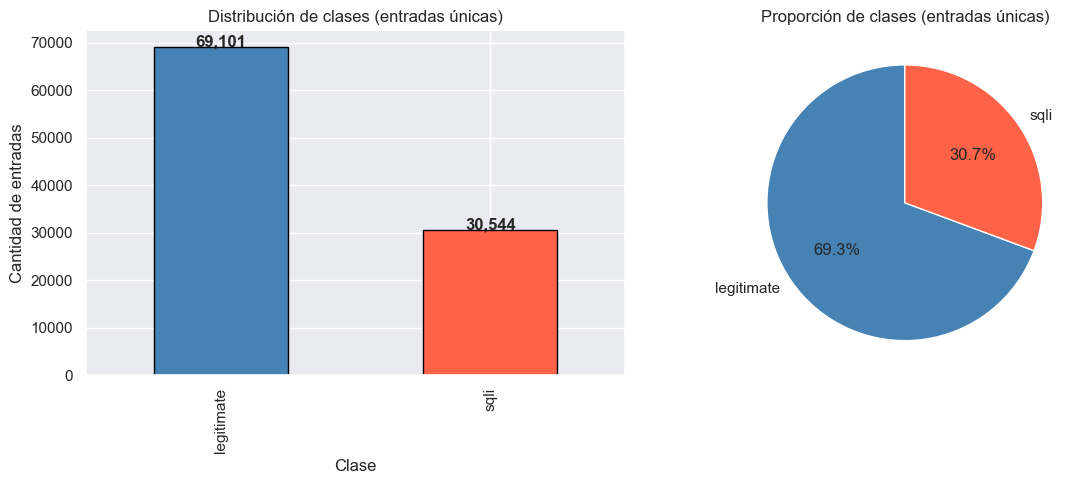


Ratio legitimate:sqli = 2.26:1


In [9]:
legit_unique    = len(df_legit) - legit_dupes
malicious_unique = len(df_malicious)

counts = pd.Series({
    "legitimate": legit_unique,
    "sqli":       malicious_unique
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Distribución de clases (entradas únicas)")
axes[0].set_ylabel("Cantidad de entradas")
axes[0].set_xlabel("Clase")
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Proporción de clases (entradas únicas)")

plt.tight_layout()
plt.show()

print(f"\nRatio legitimate:sqli = {legit_unique/malicious_unique:.2f}:1")

C:\Users\thiag\AppData\Local\Temp\ipykernel_21424\2262713637.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="label", y="payload_len",


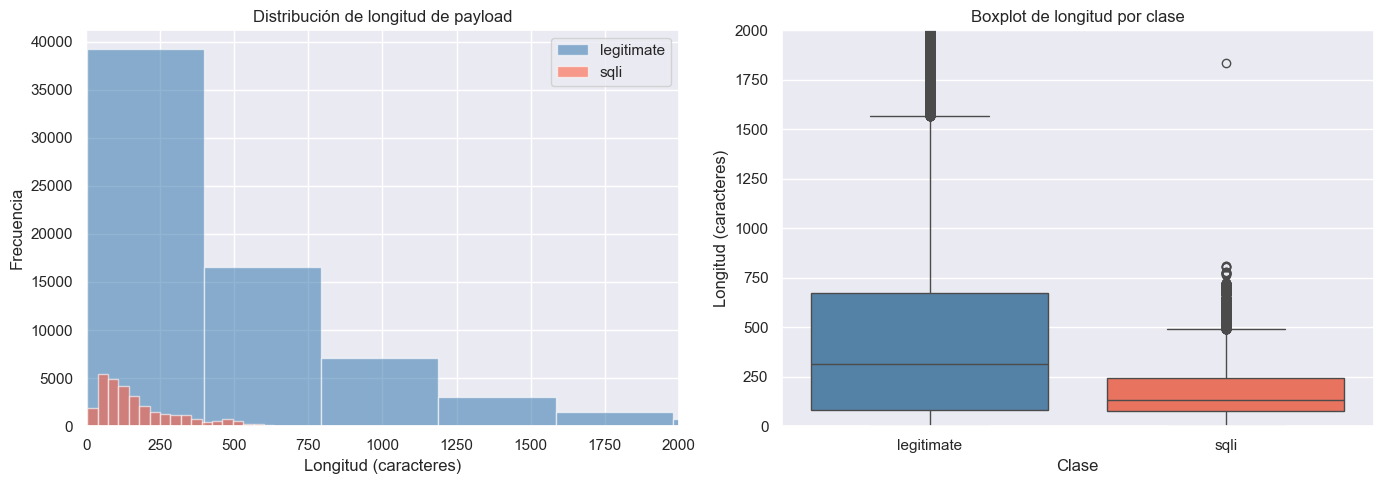

In [10]:
df_legit_unique = df_legit.drop_duplicates(subset="payload").copy()

df_combined = pd.concat([df_legit_unique, df_malicious], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [("legitimate", "steelblue"), ("sqli", "tomato")]:
    subset = df_combined[df_combined["label"] == label]["payload_len"]
    axes[0].hist(subset, bins=80, alpha=0.6, label=label, color=color)

axes[0].set_title("Distribución de longitud de payload")
axes[0].set_xlabel("Longitud (caracteres)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, 2000)
axes[0].legend()

sns.boxplot(data=df_combined, x="label", y="payload_len",
            palette={"legitimate": "steelblue", "sqli": "tomato"}, ax=axes[1])
axes[1].set_title("Boxplot de longitud por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Longitud (caracteres)")
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.show()

# --- RESUMEN AUDITORÍA MODSEC-LEARN ---


**legitimate.json**
  - Total entradas      : 508,530
  - Duplicados          : 439,429 (86.4%)
  - Entradas únicas     : 69,101
  - Longitud media      : 495 chars
  - Nulos / vacíos      : 0

**malicious.json (sqli)**
  - Total entradas      : 30,544
  - Duplicados          : 0
  - Entradas únicas     : 30,544
  - Longitud media      : 178 chars
  - Nulos / vacíos      : 0

Estado                : LISTO para pipeline

Acción requerida      : eliminar duplicados en legitimate antes de unificar

# SECCIÓN 3: AUDITORÍA OWASP LOGS

In [12]:
log_files = sorted(OWASP_DIR.rglob("*.anon.log"))

print(f"Total archivos encontrados: {len(log_files)}")
print()
for f in log_files[:10]:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.parent.name}/{f.name}  ({size_kb:.1f} KB)")

if len(log_files) > 10:
    print(f"  ... y {len(log_files) - 10} más")

Total archivos encontrados: 30

  01-Aug-2025/modsec_audit.anon.log  (15332.2 KB)
  02-Aug-2025/modsec_audit.anon.log  (13683.4 KB)
  03-Aug-2025/modsec_audit.anon.log  (13367.7 KB)
  04-Aug-2025/modsec_audit.anon.log  (18604.6 KB)
  05-Aug-2025/modsec_audit.anon.log  (11996.1 KB)
  06-Aug-2025/modsec_audit.anon.log  (9429.3 KB)
  07-Aug-2025/modsec_audit.anon.log  (5085.4 KB)
  08-Aug-2025/modsec_audit.anon.log  (6803.5 KB)
  09-Aug-2025/modsec_audit.anon.log  (9115.9 KB)
  10-Aug-2025/modsec_audit.anon.log  (18472.5 KB)
  ... y 20 más


In [13]:
sample_file = log_files[0]

with open(sample_file, "r", encoding="utf-8", errors="replace") as f:
    content = f.read()

print(f"Archivo     : {sample_file.parent.name}/{sample_file.name}")
print(f"Tamaño      : {len(content):,} caracteres")

boundaries = re.findall(r'--[a-f0-9]+-A--', content)
print(f"Transacciones encontradas: {len(boundaries):,}")

print("\n--- Primeras 80 líneas del archivo ---")
for i, line in enumerate(content.split("\n")[:80]):
    print(f"{i+1:3}  {line}")

Archivo     : 01-Aug-2025/modsec_audit.anon.log
Tamaño      : 15,700,154 caracteres
Transacciones encontradas: 5,333

--- Primeras 80 líneas del archivo ---
  1  --13f17100-A--
  2  [01/Aug/2025:00:03:24 +0200] aIvoK07UuwPqK4AR6QUCvAAAAA4 100.102.149.187 4709 100.115.127.60 80
  3  --13f17100-B--
  4  GET /wp-includesSimplePiegzdecodes.php HTTP/1.1
  5  Host: db67d3a.com
  6  Cookie: _jwp=c_ed49c20eb3eb1427; wordpress_test_cookie=c_2901f8660367e79b
  7  
  8  --13f17100-F--
  9  HTTP/1.1 404 Not Found
 10  Expires: Wed, 11 Jan 1984 05:00:00 GMT
 11  Cache-Control: no-cache, must-revalidate, max-age=0, no-store, private
 12  Link: <http://d_6fec7c8b7c.com/d_24b512b7>; rel="https://api.w.org/"
 13  Transfer-Encoding: chunked
 14  Content-Type: text/html; charset=UTF-8
 15  
 16  --13f17100-H--
 17  Message: Warning. Matched phrase "gzdecode" at REQUEST_FILENAME. [file "/usr/share/modsecurity-crs/rules/REQUEST-933-APPLICATION-ATTACK-PHP.conf"] [line "297"] [id "933150"] [msg "PHP Injectio

In [14]:
section_h_blocks = re.findall(r'--[a-f0-9]+-H--\n(.*?)(?=--[a-f0-9]+-Z--)', content, re.DOTALL)

tags = []
rule_ids = []

for block in section_h_blocks:
    tags       += re.findall(r'\[tag "([^"]+)"\]', block)
    rule_ids   += re.findall(r'\[id "(\d+)"\]', block)

tag_counts     = pd.Series(tags).value_counts()
ruleid_counts  = pd.Series(rule_ids).value_counts()

print(f"Transacciones con sección H : {len(section_h_blocks):,}")
print(f"Tags únicos encontrados     : {tag_counts.nunique():,}")
print(f"Rule IDs únicos encontrados : {ruleid_counts.nunique():,}")

print("\n--- Top 20 tags ---")
print(tag_counts.head(20).to_string())

print("\n--- Top 20 rule IDs ---")
print(ruleid_counts.head(20).to_string())

Transacciones con sección H : 5,333
Tags únicos encontrados     : 29
Rule IDs únicos encontrados : 21

--- Top 20 tags ---
application-multi                            9936
OWASP_CRS                                    9930
platform-multi                               9736
language-multi                               9430
attack-lfi                                   5606
OWASP_TOP_10/A4                              5536
WASCTC/WASC-33                               5536
OWASP_CRS/WEB_ATTACK/FILE_INJECTION          5536
PCI/6.5.4                                    5536
OWASP_TOP_10/A7                              4708
attack-protocol                              3782
PCI/12.1                                     3778
WASCTC/WASC-15                               2810
WASCTC/WASC-21                               1900
OWASP_CRS/POLICY/HEADER_RESTRICTED           1760
PCI/6.5.10                                   1188
OWASP_CRS/POLICY/EXT_RESTRICTED              1048
OWASP_TOP_10/A1            

In [15]:
attack_tag_map = {
    "attack-sqli"      : "sqli",
    "attack-xss"       : "xss",
    "attack-lfi"       : "lfi",
    "attack-rfi"       : "rfi",
    "attack-injection" : "injection",
    "attack-protocol"  : "protocol",
    "attack-php"       : "php_injection",
}

print("=== Tags de ataque presentes en este archivo ===")
for tag in attack_tag_map:
    count = tag_counts.get(tag, 0)
    print(f"  {tag:<30} -> {count:,} ocurrencias")

print("\n=== Tags presentes que NO son de ataque directo ===")
non_attack = [t for t in tag_counts.index if not t.startswith("attack-")]
for tag in non_attack[:15]:
    print(f"  {tag:<45} -> {tag_counts[tag]:,}")

=== Tags de ataque presentes en este archivo ===
  attack-sqli                    -> 2 ocurrencias
  attack-xss                     -> 10 ocurrencias
  attack-lfi                     -> 5,606 ocurrencias
  attack-rfi                     -> 2 ocurrencias
  attack-injection               -> 0 ocurrencias
  attack-protocol                -> 3,782 ocurrencias
  attack-php                     -> 0 ocurrencias

=== Tags presentes que NO son de ataque directo ===
  application-multi                             -> 9,936
  OWASP_CRS                                     -> 9,930
  platform-multi                                -> 9,736
  language-multi                                -> 9,430
  OWASP_TOP_10/A4                               -> 5,536
  WASCTC/WASC-33                                -> 5,536
  OWASP_CRS/WEB_ATTACK/FILE_INJECTION           -> 5,536
  PCI/6.5.4                                     -> 5,536
  OWASP_TOP_10/A7                               -> 4,708
  PCI/12.1                

In [16]:
attack_counts_all = {"sqli": 0, "xss": 0, "lfi": 0, "protocol": 0, "other": 0}
total_transactions = 0

for log_file in log_files:
    with open(log_file, "r", encoding="utf-8", errors="replace") as f:
        c = f.read()

    total_transactions += len(re.findall(r'--[a-f0-9]+-A--', c))

    blocks = re.findall(r'--[a-f0-9]+-H--\n(.*?)(?=--[a-f0-9]+-Z--)', c, re.DOTALL)
    for block in blocks:
        tags_in_block = re.findall(r'\[tag "([^"]+)"\]', block)
        if "attack-sqli" in tags_in_block:
            attack_counts_all["sqli"] += 1
        elif "attack-xss" in tags_in_block:
            attack_counts_all["xss"] += 1
        elif "attack-lfi" in tags_in_block:
            attack_counts_all["lfi"] += 1
        elif "attack-protocol" in tags_in_block:
            attack_counts_all["protocol"] += 1
        else:
            attack_counts_all["other"] += 1

print(f"Total transacciones en los 30 archivos : {total_transactions:,}")
print(f"\n=== Distribución por tipo de ataque ===")
for k, v in attack_counts_all.items():
    print(f"  {k:<12} -> {v:,}")

Total transacciones en los 30 archivos : 142,705

=== Distribución por tipo de ataque ===
  sqli         -> 4,064
  xss          -> 260
  lfi          -> 49,771
  protocol     -> 36,857
  other        -> 51,753


## --- PARSER COMPLETO OWASP LOGS ---

In [17]:
def parse_owasp_log(filepath):
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()

    transactions = re.split(r'(?=--[a-f0-9]+-A--)', content)
    records = []

    for tx in transactions:
        if not tx.strip():
            continue

        record = {
            "timestamp"    : None,
            "source_ip"    : None,
            "method"       : None,
            "path"         : None,
            "query_string" : None,
            "status_code"  : None,
            "label"        : None,
            "rule_ids"     : None,
        }

        sec_a = re.search(r'-A--\n(.+)', tx)
        if sec_a:
            a_line = sec_a.group(1)
            ts_match = re.search(r'\[(.+?)\]', a_line)
            ip_match = re.search(r'\]\s+\S+\s+(\d+\.\d+\.\d+\.\d+)', a_line)
            if ts_match:
                record["timestamp"] = ts_match.group(1)
            if ip_match:
                record["source_ip"] = ip_match.group(1)

        sec_b = re.search(r'-B--\n(.*?)(?=--[a-f0-9]+-)', tx, re.DOTALL)
        if sec_b:
            first_line = sec_b.group(1).strip().split("\n")[0]
            parts = first_line.split(" ")
            if len(parts) >= 2:
                record["method"] = parts[0]
                full_path = parts[1]
                if "?" in full_path:
                    record["path"], record["query_string"] = full_path.split("?", 1)
                else:
                    record["path"] = full_path

        sec_f = re.search(r'-F--\n(.*?)(?=--[a-f0-9]+-)', tx, re.DOTALL)
        if sec_f:
            status_line = sec_f.group(1).strip().split("\n")[0]
            st_match = re.search(r'HTTP/\S+\s+(\d+)', status_line)
            if st_match:
                record["status_code"] = int(st_match.group(1))

        sec_h = re.search(r'-H--\n(.*?)(?=--[a-f0-9]+-)', tx, re.DOTALL)
        if sec_h:
            h_content  = sec_h.group(1)
            tags_found = re.findall(r'\[tag "([^"]+)"\]', h_content)
            ids_found  = re.findall(r'\[id "(\d+)"\]', h_content)
            record["rule_ids"] = ",".join(ids_found)

            if "attack-sqli" in tags_found:
                record["label"] = "sqli"
            elif "attack-xss" in tags_found:
                record["label"] = "xss"
            else:
                record["label"] = "out_of_scope"
        else:
            record["label"] = "out_of_scope"

        if record["method"]:
            records.append(record)

    return pd.DataFrame(records)

In [18]:
print("Procesando 30 archivos...")
dfs = []
for log_file in log_files:
    df_day = parse_owasp_log(log_file)
    dfs.append(df_day)
    print(f"  {log_file.parent.name}  -> {len(df_day):,} transacciones")

df_owasp = pd.concat(dfs, ignore_index=True)
print(f"\nTotal parseado: {len(df_owasp):,} transacciones")

Procesando 30 archivos...
  01-Aug-2025  -> 5,333 transacciones
  02-Aug-2025  -> 5,695 transacciones
  03-Aug-2025  -> 4,635 transacciones
  04-Aug-2025  -> 8,196 transacciones
  05-Aug-2025  -> 5,340 transacciones
  06-Aug-2025  -> 3,564 transacciones
  07-Aug-2025  -> 1,997 transacciones
  08-Aug-2025  -> 2,579 transacciones
  09-Aug-2025  -> 3,131 transacciones
  10-Aug-2025  -> 7,404 transacciones
  11-Aug-2025  -> 3,119 transacciones
  12-Aug-2025  -> 2,473 transacciones
  13-Aug-2025  -> 4,735 transacciones
  14-Aug-2025  -> 11,802 transacciones
  15-Aug-2025  -> 14,755 transacciones
  16-Aug-2025  -> 8,886 transacciones
  17-Aug-2025  -> 4,381 transacciones
  18-Aug-2025  -> 3,348 transacciones
  19-Aug-2025  -> 3,932 transacciones
  20-Aug-2025  -> 2,774 transacciones
  21-Aug-2025  -> 2,813 transacciones
  22-Aug-2025  -> 2,585 transacciones
  23-Aug-2025  -> 3,558 transacciones
  24-Aug-2025  -> 3,330 transacciones
  25-Aug-2025  -> 3,695 transacciones
  27-Jul-2025  -> 2,86

In [19]:
print("=== Distribución de labels ===")
print(df_owasp["label"].value_counts().to_string())

print("\n=== Nulos por columna ===")
print(df_owasp.isnull().sum().to_string())

print("\n=== Muestra de registros SQLI ===")
print(df_owasp[df_owasp["label"] == "sqli"][["timestamp","method","path","query_string","status_code"]].head(3).to_string())

print("\n=== Muestra de registros XSS ===")
print(df_owasp[df_owasp["label"] == "xss"][["timestamp","method","path","query_string","status_code"]].head(3).to_string())

=== Distribución de labels ===
label
out_of_scope    138381
sqli              4064
xss                260

=== Nulos por columna ===
timestamp            0
source_ip            0
method               0
path                 0
query_string    134163
status_code          0
label                0
rule_ids             0

=== Muestra de registros SQLI ===
                       timestamp method           path query_string  status_code
3308  01/Aug/2025:16:40:10 +0200   POST  /wp-login.php         None          503
7484  02/Aug/2025:05:18:07 +0200    GET              /         None          301
7485  02/Aug/2025:05:18:07 +0200    GET    /xmlrpc.php          rsd          301

=== Muestra de registros XSS ===
                       timestamp method                    path                                                                                                                                                                              query_string  status_code
3875  01/Aug/2025:19:30:31 

# -- RESUMEN AUDITORÍA OWASP LOGS --

Archivos procesados         : 30

Total transacciones         : 142,705

  - out_of_scope              : 138,381
  - sqli                      : 4,064
  - xss                       : 260

In-scope total              : 4,324

Query string disponible     : 1,445 / 4324

Cobertura de ataques        :
  - sqli   -> cubierto (OWASP + modsec-learn)
  - xss    -> cubierto (OWASP únicamente por ahora)
  - ddos   -> NO cubierto, requiere tráfico sintético
  - brute  -> NO cubierto, requiere tráfico sintético

Estado                      : LISTO para pipeline

Acción requerida            : descartar out_of_scope antes de unificar